## Spatial Data Observations

### General

- GeoJSON contains 55 neighborhood polygons covering Singapore
- Dataset only has 3 columns:
    - `neighborhood`
    - `neighborhood_group`
    - `geometry`
- No missing values were found
- Spatial dataset appears to be significantly cleaner than the tabular dataset

### Coordinate System

- CRS is `EPSG:4326 (WGS84)`
- Matches the lattitude/longitude coordinates used in the spatial dataset
- No coordinate conversion should be required when combining the datasets

### Geometry

- All geometries are `multipolygon` objects
- Polygon boundaries appear normal and valid when plotted
- Coverage includes mainland Singapore and the surrounding islands

### Relationship to the tabular dataset

- All neighborhoods present in the tabular dataset are represented in the GeoJSON
- The GeoJSON contains several additional neighborhoods with no Airbnb listings
- There are no naming inconsistencies between the two datasets
- Therefore, spatial joins are not required to assign neighborhood labels to listings

### Potential Uses

- Neighborhood-level aggregation and analysis
- Geographic visualization and choropleth maps
- Spatial feature engineering using lattitude and longitude
- Distance-based features:
    - Airport proximity
    - CBD proximity
    - MRT proximity (If external data exists)

### Current Assessment

- Spatial data is immediately useable
- No major preprocessing seems to be required
- Most effort will likely be spent on feature engineering rather than data cleaning

In [1]:
import geopandas as gpd
from src.utils.paths import RAW_DATA_DIR

In [3]:
gdf = gpd.read_file(RAW_DATA_DIR / "neighbourhoods.geojson")

In [4]:
gdf.head()

,neighbourhood,neighbourhood_group,geometry
0,Pasir Ris,East Region,"MULTIPOLYGON (((103.95322 1.38202, 103.9535 1...."
1,Seletar,North-East Region,"MULTIPOLYGON (((103.88691 1.42649, 103.88812 1..."
2,Sungei Kadut,North Region,"MULTIPOLYGON (((103.7644 1.44345, 103.76443 1...."
3,Orchard,Central Region,"MULTIPOLYGON (((103.84298 1.30001, 103.84294 1..."
4,Downtown Core,Central Region,"MULTIPOLYGON (((103.85942 1.29978, 103.85954 1..."


In [5]:
gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 55 entries, 0 to 54
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   neighbourhood        55 non-null     str     
 1   neighbourhood_group  55 non-null     str     
 2   geometry             55 non-null     geometry
dtypes: geometry(1), str(2)
memory usage: 1.4 KB


In [6]:
gdf.columns.tolist()

['neighbourhood', 'neighbourhood_group', 'geometry']

In [7]:
gdf.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [8]:
gdf.geometry.geom_type.value_counts()

MultiPolygon    55
Name: count, dtype: int64

<Axes: >

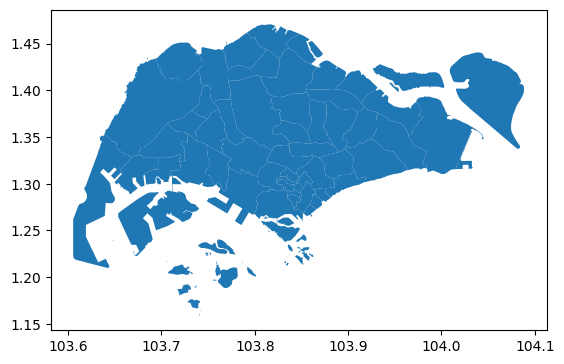

In [9]:
gdf.plot()

In [10]:
len(gdf)

55

In [11]:
gdf["neighbourhood"].unique()

<StringArray>
[              'Pasir Ris',                 'Seletar',
            'Sungei Kadut',                 'Orchard',
           'Downtown Core',                 'Kallang',
                   'Bedok',                 'Simpang',
            'Marina South',                  'Changi',
               'Sembawang',             'Jurong East',
                 'Pioneer',                'Boon Lay',
             'Bukit Merah', 'Western Water Catchment',
               'Woodlands',                  'Mandai',
                'Sengkang',              'Queenstown',
   'North-Eastern Islands',                  'Tengah',
        'Southern Islands', 'Central Water Catchment',
                  'Outram',                  'Newton',
           'Marine Parade',            'Straits View',
                  'Yishun',              'Ang Mo Kio',
             'Jurong West',           'Choa Chu Kang',
           'Bukit Panjang',         'Singapore River',
                 'Tanglin',                 'Geylan